# Phase 3 — Findings Notebook

Every finding recorded in `pipeline_report.md`, reproduced from the canonical tables with
code, output and figures.

The pipeline is `phase3_pipeline/` and the tables it produces live in `data/processed/`.
Rebuild them with:

```bash
python -m phase3_pipeline.build_dataset
```

**What this notebook covers**

| # | Finding | Why it mattered |
|---|---|---|
| 1 | Discharge records continue past load removal | duration/energy wrong by ~9% on every cycle |
| 2 | Operation ordering differs between batteries | charge/discharge pairing would mis-align |
| 3 | Cycle 1 is a partial charge on all four cells | inverts the meaning of the best health indicator |
| 4 | Five aborted charge operations | meaningless charge features |
| 5 | Early-life discharges overshoot the cut-off | unresolved; may distort early capacity |
| 6 | Identical telemetry volumes across three cells | confirms synchronous testbed, not a bug |

It then covers the **targets** (SOH, EOL, RUL), **capacity regeneration**, and the
**physical validation** that the parser recovers known battery behaviour.

## Setup

In [1]:
%matplotlib inline
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.io import loadmat

from common.config import load_config, resolve

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

CFG = load_config()

# Categorical slots 1-4 of the reference data-viz palette, used in documented
# order. Line charts use the adjacent pairlist, which this order is validated
# against. Slot 4 (yellow) sits below 3:1 contrast on a light surface, so every
# series is also direct-labelled rather than identified by colour alone.
SERIES = {"B0005": "#2a78d6", "B0006": "#eb6834", "B0007": "#1baf7a", "B0018": "#eda100"}
BATTERIES = list(SERIES)
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE = "#e6e5e1", "#fcfcfb"
ACCENT_BAD = "#e34948"   # status red, reserved for flagged/defective data

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 110,
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.titleweight": "semibold", "axes.titlepad": 10,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "legend.frameon": False, "lines.linewidth": 1.6,
    "figure.autolayout": False,
})

def style(ax, title=None, xlabel=None, ylabel=None, grid_axis="y"):
    "Recessive axes: no top/right spines, thin grid behind the marks."
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.7, alpha=0.9)
    ax.set_axisbelow(True)
    if title:  ax.set_title(title, color=INK, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    return ax

print("matplotlib", mpl.__version__, "| pandas", pd.__version__)

matplotlib 3.11.2 | pandas 3.0.5


In [2]:
P = resolve("processed")
cyc = pd.read_parquet(P / "cycle_summary.parquet")
tel = pd.read_parquet(P / "telemetry.parquet")
imp = pd.read_parquet(P / "impedance.parquet")
regen = pd.read_parquet(P / "regeneration_summary.parquet")

print(f"cycle_summary  {cyc.shape[0]:>9,} rows x {cyc.shape[1]} cols")
print(f"telemetry      {tel.shape[0]:>9,} rows x {tel.shape[1]} cols")
print(f"impedance      {imp.shape[0]:>9,} rows x {imp.shape[1]} cols")
print(f"regeneration   {regen.shape[0]:>9,} rows x {regen.shape[1]} cols")
print()
print(cyc.groupby("battery_id").agg(
    cycles=("cycle_id", "size"),
    cap_first=("capacity_ah", "first"),
    cap_last=("capacity_ah", "last"),
    eol=("eol_cycle", "first"),
    censored=("is_censored", "first"),
    flagged=("qc_any", "sum"),
).round(3).to_string())

cycle_summary        636 rows x 66 cols
telemetry      2,089,050 rows x 11 cols
impedance            887 rows x 6 cols
regeneration           4 rows x 7 cols

            cycles  cap_first  cap_last    eol  censored  flagged
battery_id                                                       
B0005          168      1.856     1.325  125.0     False        2
B0006          168      2.035     1.186  109.0     False        9
B0007          168      1.891     1.432    NaN      True       16
B0018          132      1.855     1.341   97.0     False        3


---

## Finding 1 — discharge records continue past load removal

Each discharge record does **not** stop when the cell hits its cut-off voltage. The logger
keeps sampling after the load is disconnected, through a relaxation period where the
terminal voltage climbs back up.

If you take `Time[-1]` as the discharge duration and `Voltage_measured[-1]` as the end
voltage — the obvious thing to do — both are wrong. Below is B0005 cycle 1 with the
active segment separated from the tail.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


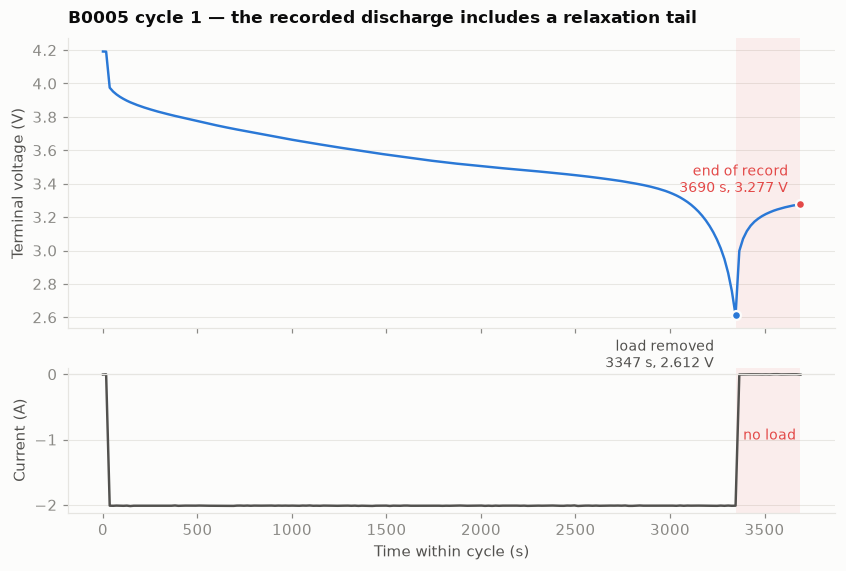

record duration          3690 s
active discharge         3347 s
relaxation tail           343 s  (9.3% of record)
voltage at cut-off      2.612 V
voltage at end          3.277 V   <- NOT the cut-off
recovery                0.665 V


In [3]:
m = loadmat(str(resolve("raw_nasa") / CFG["tier1"]["bundle"] / "B0005.mat"), simplify_cells=True)
ops = np.atleast_1d(m["B0005"]["cycle"])
d = [o for o in ops if o["type"] == "discharge"][0]["data"]

t = np.asarray(d["Time"], float)
v = np.asarray(d["Voltage_measured"], float)
i = np.asarray(d["Current_measured"], float)

active = np.abs(i) > CFG["ingestion"]["active_current_a"]
last = np.where(active)[0][-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1], "hspace": 0.18})

ax1.axvspan(t[last], t[-1], color=ACCENT_BAD, alpha=0.08, lw=0)
ax1.plot(t, v, color=SERIES["B0005"])
ax1.scatter([t[last]], [v[last]], s=34, color=SERIES["B0005"], zorder=5,
            edgecolor=SURFACE, linewidth=1.5)
ax1.scatter([t[-1]], [v[-1]], s=34, color=ACCENT_BAD, zorder=5,
            edgecolor=SURFACE, linewidth=1.5)
ax1.annotate(f"load removed\n{t[last]:.0f} s, {v[last]:.3f} V",
             (t[last], v[last]), textcoords="offset points", xytext=(-14, -34),
             ha="right", fontsize=9, color=INK2)
ax1.annotate(f"end of record\n{t[-1]:.0f} s, {v[-1]:.3f} V",
             (t[-1], v[-1]), textcoords="offset points", xytext=(-8, 8),
             ha="right", fontsize=9, color=ACCENT_BAD)
style(ax1, "B0005 cycle 1 — the recorded discharge includes a relaxation tail",
      ylabel="Terminal voltage (V)")

ax2.axvspan(t[last], t[-1], color=ACCENT_BAD, alpha=0.08, lw=0)
ax2.plot(t, i, color=INK2)
ax2.axhline(0, color=GRID, lw=0.8)
style(ax2, None, "Time within cycle (s)", "Current (A)")
ax2.text(t[last] + 40, -1.0, "no load", fontsize=9, color=ACCENT_BAD)

plt.show()

print(f"record duration      {t[-1]:8.0f} s")
print(f"active discharge     {t[last]:8.0f} s")
print(f"relaxation tail      {t[-1]-t[last]:8.0f} s  ({(t[-1]-t[last])/t[-1]*100:.1f}% of record)")
print(f"voltage at cut-off   {v[last]:8.3f} V")
print(f"voltage at end       {v[-1]:8.3f} V   <- NOT the cut-off")
print(f"recovery             {v[-1]-v[last]:8.3f} V")

The error is not a one-off. Across every cycle of every battery the tail is a consistent
fraction of the record, so using the raw array would bias **every** duration and energy
feature in the same direction — the kind of error that stays invisible because nothing
looks anomalous.

The tail is kept rather than discarded: voltage recovery grows with internal resistance,
so `v_recovery_v` is a health signal in its own right.

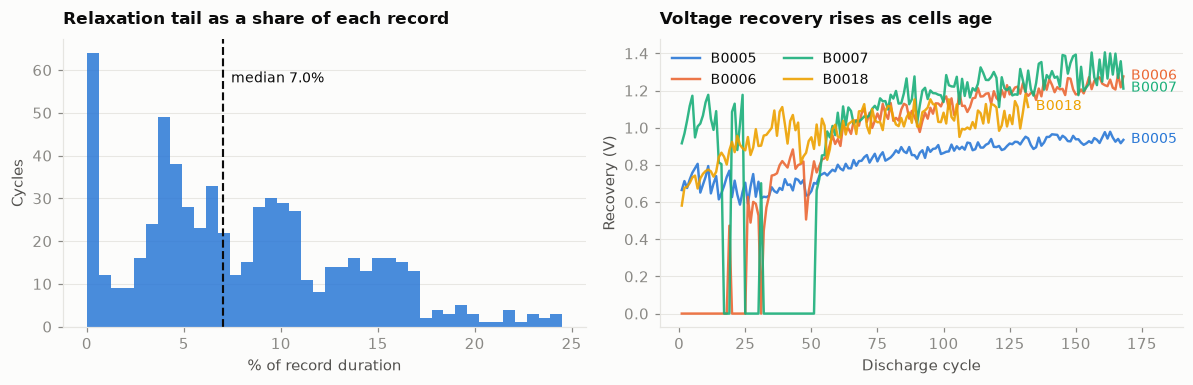

            tail_pct_median  recovery_first  recovery_last
battery_id                                                
B0005                   9.4           0.665          0.935
B0006                  12.7           0.000          1.276
B0007                   3.9           0.916          1.211
B0018                   8.9           0.581          1.112


In [4]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(11, 3.6))

frac = cyc["relax_duration_s"] / cyc["record_duration_s"] * 100
axl.hist(frac.dropna(), bins=40, color=SERIES["B0005"], alpha=0.85)
axl.axvline(frac.median(), color=INK, lw=1.4, ls="--")
axl.text(frac.median() + 0.4, axl.get_ylim()[1]*0.85,
         f"median {frac.median():.1f}%", fontsize=9, color=INK)
style(axl, "Relaxation tail as a share of each record", "% of record duration", "Cycles")

for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    axr.plot(g.cycle_id, g.v_recovery_v, color=SERIES[b], label=b, alpha=0.9)
    axr.annotate(b, (g.cycle_id.iloc[-1], g.v_recovery_v.iloc[-1]),
                 textcoords="offset points", xytext=(5, -2), fontsize=9, color=SERIES[b])
style(axr, "Voltage recovery rises as cells age", "Discharge cycle", "Recovery (V)")
axr.legend(loc="upper left", fontsize=9, ncols=2)
axr.set_xlim(right=axr.get_xlim()[1] * 1.08)
plt.tight_layout(); plt.show()

print(cyc.groupby("battery_id").agg(
    tail_pct_median=("relax_duration_s", lambda s: round(
        float((s / cyc.loc[s.index, "record_duration_s"]).median() * 100), 1)),
    recovery_first=("v_recovery_v", "first"),
    recovery_last=("v_recovery_v", "last"),
).round(3).to_string())

---

## Finding 2 — operation ordering differs between batteries

The raw file is a flat sequence of operations. It is tempting to assume a fixed
charge → discharge → impedance repeat and pair records by stride. That assumption breaks:
B0005 alternates charge/discharge with impedance appearing later, while B0018 interleaves
impedance from the very first cycle.

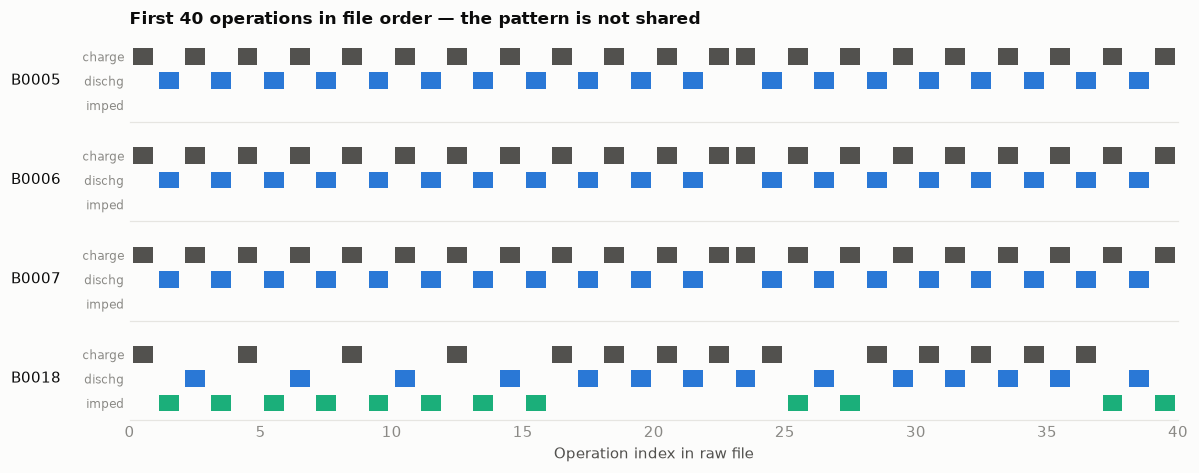

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(11, 4.4), sharex=True)
LANE = {"charge": (2, INK2), "discharge": (1, SERIES["B0005"]), "impedance": (0, SERIES["B0007"])}

for ax, b in zip(axes, BATTERIES):
    mm = loadmat(str(resolve("raw_nasa") / CFG["tier1"]["bundle"] / f"{b}.mat"), simplify_cells=True)
    types = [str(o["type"]) for o in np.atleast_1d(mm[b]["cycle"])][:40]
    for k, ty in enumerate(types):
        lane, colr = LANE[ty]
        ax.add_patch(plt.Rectangle((k + 0.12, lane - 0.34), 0.76, 0.68,
                                   color=colr, lw=0))
    ax.set_ylim(-0.7, 2.7); ax.set_xlim(0, 40)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["imped", "dischg", "charge"], fontsize=8)
    ax.set_ylabel(b, rotation=0, ha="right", va="center", fontsize=10, color=INK, labelpad=14)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(length=0)
    ax.grid(False)

axes[0].set_title("First 40 operations in file order — the pattern is not shared",
                  color=INK, loc="left")
axes[-1].set_xlabel("Operation index in raw file")
plt.tight_layout(); plt.show()

This is why pairing is positional (`merge_asof` on `op_index`) rather than stride-based.

It also explains an asymmetry in the impedance join. B0005/6/7 record no impedance until
after cycle 19, so those cycles have no impedance value to carry backward — 57 null rows
in total. B0018 has impedance from cycle 1 but measures it far less often afterwards.

In [6]:
print("cycles with no impedance available yet (leading gap):")
print(cyc[cyc.re_ohm.isna()].groupby("battery_id").cycle_id.agg(
    n_cycles="size", last_cycle="max").to_string())
print()
print("impedance staleness, in raw operations, once available:")
print(cyc.groupby("battery_id").impedance_age_ops.agg(["mean", "median", "max"]).round(1).to_string())
print()
print("A negative staleness would mean a future measurement leaked backward in time.")
print("min across all rows:", cyc.impedance_age_ops.min())

cycles with no impedance available yet (leading gap):
            n_cycles  last_cycle
battery_id                      
B0005             19          19
B0006             19          19
B0007             19          19

impedance staleness, in raw operations, once available:
            mean  median   max
battery_id                    
B0005        1.2     1.0   5.0
B0006        1.2     1.0   5.0
B0007        1.2     1.0   5.0
B0018        4.6     4.0  13.0

A negative staleness would mean a future measurement leaked backward in time.
min across all rows: 1.0


---

## Findings 3 & 4 — partial and aborted charge operations

CC-charge duration is one of the strongest health indicators available: it shortens as a
cell ages. That makes it acutely sensitive to malformed charge records, because a short CC
phase caused by a *logging problem* is indistinguishable from a short CC phase caused by
*degradation* unless you check.

Two distinct defects show up.

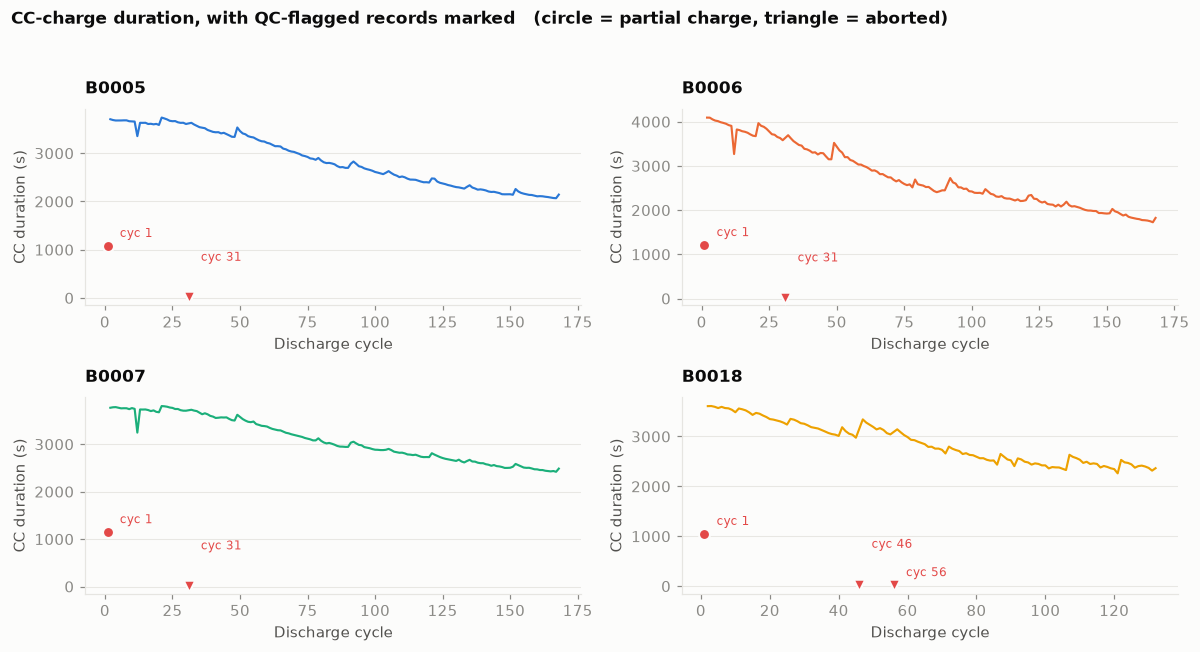

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=False)

for ax, b in zip(axes.ravel(), BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    ok = g[~g.qc_charge_aborted & ~g.qc_charge_partial]
    ax.plot(ok.cycle_id, ok.cc_duration_s, color=SERIES[b], lw=1.4)

    part = g[g.qc_charge_partial]
    abrt = g[g.qc_charge_aborted]
    ax.scatter(part.cycle_id, part.cc_duration_s, s=52, color=ACCENT_BAD,
               zorder=5, edgecolor=SURFACE, linewidth=1.4, marker="o")
    ax.scatter(abrt.cycle_id, abrt.cc_duration_s, s=58, color=ACCENT_BAD,
               zorder=5, edgecolor=SURFACE, linewidth=1.4, marker="v")
    flagged = pd.concat([part, abrt]).sort_values("cycle_id")
    for k, (_, r) in enumerate(flagged.iterrows()):
        # Stagger upward only: the markers sit near y=0, so a downward offset
        # would put the label on top of the x-axis tick labels.
        dy = 6 if k % 2 == 0 else 24
        ax.annotate(f"cyc {int(r.cycle_id)}", (r.cycle_id, r.cc_duration_s),
                    textcoords="offset points", xytext=(8, dy), fontsize=8,
                    color=ACCENT_BAD)
    style(ax, b, "Discharge cycle", "CC duration (s)")
    ax.set_ylim(bottom=-150)

fig.suptitle("CC-charge duration, with QC-flagged records marked   "
             "(circle = partial charge, triangle = aborted)",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

**Finding 3 — cycle 1 is a partial charge on every cell.** The experiment began with
partly charged cells, so the first charge delivers roughly 0.8 Ah against a ~1.9 Ah norm.
Left unflagged this reads as "a healthy cell with a short CC phase" — exactly inverting
the indicator's meaning, at the very cycle other features are normalised against.

**Finding 4 — five charge records are effectively empty.** Note that B0005, B0006 and
B0007 all fail at *the same cycle*, 31. That is one testbed interruption, not three
independent cell faults.

In [8]:
print("Finding 3 — partial charges (charge_ah < 0.8 x capacity_ah):")
print(cyc[cyc.qc_charge_partial][
    ["battery_id", "cycle_id", "charge_ah", "capacity_ah", "cc_duration_s"]
].round(2).to_string(index=False))

print()
print("Finding 4 — aborted charges (cc_duration < 60 s or charge_ah < 0.1):")
print(cyc[cyc.qc_charge_aborted][
    ["battery_id", "cycle_id", "cc_duration_s", "charge_ah"]
].round(2).to_string(index=False))

print()
print("For scale, normal CC duration by battery:")
print(cyc[~cyc.qc_any].groupby("battery_id").cc_duration_s.describe()[
    ["min", "50%", "max"]].round(0).to_string())

Finding 3 — partial charges (charge_ah < 0.8 x capacity_ah):
battery_id  cycle_id  charge_ah  capacity_ah  cc_duration_s
     B0005         1       0.78         1.86        1072.95
     B0006         1       0.85         2.04        1204.59
     B0007         1       0.81         1.89        1141.09
     B0018         1       0.78         1.86        1042.06

Finding 4 — aborted charges (cc_duration < 60 s or charge_ah < 0.1):
battery_id  cycle_id  cc_duration_s  charge_ah
     B0005        31           9.03       0.01
     B0006        31           9.03       0.04
     B0007        31           9.03       0.03
     B0018        46          32.39       0.17
     B0018        56          15.44       0.03

For scale, normal CC duration by battery:
               min     50%     max
battery_id                        
B0005       2067.0  2785.0  3739.0
B0006       1726.0  2514.0  4093.0
B0007       2419.0  2950.0  3800.0
B0018       2261.0  2792.0  3610.0


---

## Finding 5 — early-life discharges overshoot the documented cut-off

**This one is open, not resolved.** The bundle README documents a per-cell discharge
cut-off. 21 cycles go materially below theirs, and they cluster in early life.

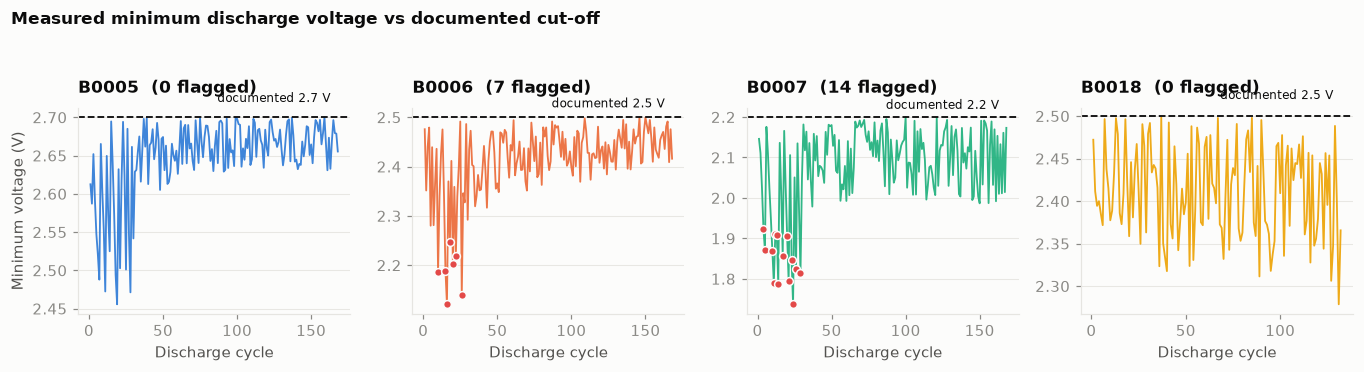

            documented  vmin_median  vmin_lowest  n_flagged
battery_id                                                 
B0005              2.7        2.660        2.456          0
B0006              2.5        2.429        2.121          7
B0007              2.2        2.102        1.737         14
B0018              2.5        2.415        2.279          0


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.4), sharey=False)

for ax, b in zip(axes, BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    nominal = CFG["cutoff_voltage_v"][b]
    bad = g[g.qc_cutoff_mismatch]
    ax.plot(g.cycle_id, g.v_min_v, color=SERIES[b], lw=1.2, alpha=0.9)
    ax.scatter(bad.cycle_id, bad.v_min_v, s=26, color=ACCENT_BAD, zorder=5,
               edgecolor=SURFACE, linewidth=1.0)
    ax.axhline(nominal, color=INK, lw=1.2, ls="--")
    ax.text(g.cycle_id.max()*0.97, nominal + 0.02, f"documented {nominal} V",
            fontsize=8, color=INK, ha="right")
    style(ax, f"{b}  ({len(bad)} flagged)", "Discharge cycle",
          "Minimum voltage (V)" if b == "B0005" else None)

fig.suptitle("Measured minimum discharge voltage vs documented cut-off",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

print(cyc.groupby("battery_id").agg(
    documented=("cutoff_nominal_v", "first"),
    vmin_median=("v_min_v", "median"),
    vmin_lowest=("v_min_v", "min"),
    n_flagged=("qc_cutoff_mismatch", "sum"),
).round(3).to_string())

Two separate effects:

1. **A systematic undershoot.** Every cell's median minimum sits 0.04–0.10 V *below* its
   documented cut-off. With a 9–19 s sampling interval the cut-off simply triggers a
   sample late. Benign.
2. **A large early-life overshoot.** B0006 cycles 10–26 and B0007 cycles 4–29 go
   ~0.3 V deeper than documented. Not benign — a deeper discharge extracts more charge,
   so the measured capacity at those cycles may overstate the cell's true health.

Carried into Phase 4 as an open question: does the early capacity trajectory of B0006 and
B0007 show a distortion over exactly these cycle ranges?

---

## Finding 6 — identical telemetry volumes are real, not a bug

B0005, B0006 and B0007 each produce exactly the same number of telemetry rows. That looks
like a parser bug — the same file read three times — so it needed ruling out.

In [10]:
chk = tel.groupby("battery_id").agg(
    rows=("voltage_v", "size"),
    voltage_sum=("voltage_v", "sum"),
    voltage_mean=("voltage_v", "mean"),
    current_sum=("current_a", "sum"),
).round(4)
print(chk.to_string())

same_rows = chk.loc[["B0005", "B0006", "B0007"], "rows"].nunique() == 1
same_data = chk.loc[["B0005", "B0006", "B0007"], "voltage_sum"].nunique() == 1
print()
print(f"identical row counts : {same_rows}")
print(f"identical values     : {same_data}   <- must be False")
print()
print("Same testbed, same protocol, synchronous logging - consistent with all three")
print("cells failing their charge at cycle 31 (Finding 4).")

              rows   voltage_sum  voltage_mean  current_sum
battery_id                                                 
B0005       591458  2.427311e+06        4.1039  218487.1490
B0006       591458  2.427482e+06        4.1042  212536.3454
B0007       591458  2.424825e+06        4.0997  228879.3213
B0018       314676  1.282809e+06        4.0766   96310.2285

identical row counts : True
identical values     : False   <- must be False

Same testbed, same protocol, synchronous logging - consistent with all three
cells failing their charge at cycle 31 (Finding 4).


---

## Targets — SOH, EOL and RUL

EOL is defined on **absolute capacity (1.4 Ah)**, matching NASA's own criterion, rather
than on a fixed SOH percentage. The reason is visible in the first chart: measured initial
capacities range 1.856–2.035 Ah, so a fixed SOH threshold would sit at a different
physical capacity for every cell.

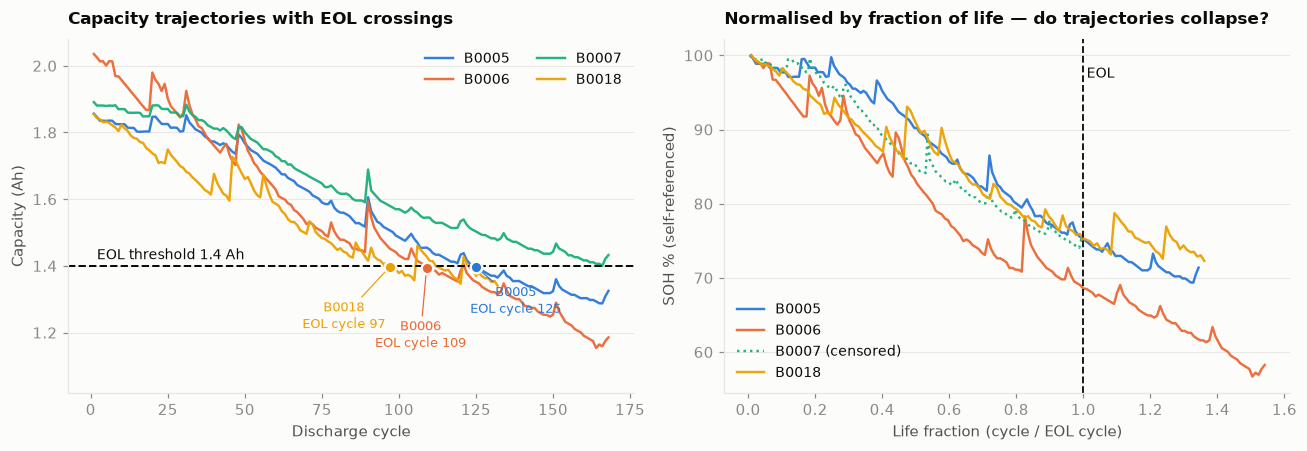

In [11]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 4.2))
eol_cap = CFG["targets"]["eol_capacity_ah"]

# EOL markers sit within ~28 cycles of each other at the same y, so the labels
# are staggered on leader lines rather than placed at a uniform offset.
EOL_LABEL = {"B0018": (-30, -40), "B0006": (-4, -52), "B0005": (26, -30)}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    axl.plot(g.cycle_id, g.capacity_ah, color=SERIES[b], label=b, alpha=0.95)
    e = g.eol_cycle.iloc[0]
    if pd.notna(e):
        row = g[g.cycle_id == int(e)].iloc[0]
        axl.scatter([row.cycle_id], [row.capacity_ah], s=58, color=SERIES[b],
                    zorder=6, edgecolor=SURFACE, linewidth=1.6)
        axl.annotate(f"{b}\nEOL cycle {int(e)}", (row.cycle_id, row.capacity_ah),
                     textcoords="offset points", xytext=EOL_LABEL[b], fontsize=8.5,
                     color=SERIES[b], ha="center",
                     arrowprops=dict(arrowstyle="-", color=SERIES[b], lw=0.8,
                                     shrinkA=0, shrinkB=4))
axl.axhline(eol_cap, color=INK, lw=1.3, ls="--")
axl.text(2, eol_cap + 0.02, f"EOL threshold {eol_cap} Ah", fontsize=9, color=INK)
style(axl, "Capacity trajectories with EOL crossings", "Discharge cycle", "Capacity (Ah)")
axl.set_ylim(bottom=1.02)
axl.legend(loc="upper right", fontsize=9, ncols=2)

for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id")
    if g.is_censored.iloc[0]:
        axr.plot(g.cycle_id / g.cycle_id.max(), g.soh_pct_self, color=SERIES[b],
                 ls=":", label=f"{b} (censored)", alpha=0.95)
    else:
        axr.plot(g.life_fraction, g.soh_pct_self, color=SERIES[b], label=b, alpha=0.95)
axr.axvline(1.0, color=INK, lw=1.2, ls="--")
axr.text(1.01, 97, "EOL", fontsize=9, color=INK)
style(axr, "Normalised by fraction of life — do trajectories collapse?",
      "Life fraction (cycle / EOL cycle)", "SOH % (self-referenced)")
axr.legend(loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

The right-hand chart is the one that governs how much cross-battery generalisation is
realistic. The three uncensored cells fall on a broadly similar path, but they are not
identical — and B0007 (dotted, censored, plotted against its own cycle range because it
has no EOL) sits visibly above the rest.

**B0007 never reaches EOL.** Its minimum capacity is 1.4005 Ah — it comes within 0.5 mAh
of the threshold and the experiment stops. It is right-censored, so it carries no RUL
label at all.

In [12]:
print(cyc.groupby("battery_id").agg(
    cap_first=("capacity_ah", "first"),
    cap_min=("capacity_ah", "min"),
    soh0_self=("soh_pct_self", "first"),
    soh0_rated=("soh_pct_rated", "first"),
    eol_cycle=("eol_cycle", "first"),
    eol_first_touch=("eol_first_touch_cycle", "first"),
    censored=("is_censored", "first"),
).round(3).to_string())

print()
print("B0007 margin to EOL: %.6f Ah" % (cyc[cyc.battery_id == "B0007"].capacity_ah.min() - 1.4))
print("rows with a usable RUL label: %d of %d" % (cyc.rul_valid.sum(), len(cyc)))
print()
print("Note eol_cycle == eol_first_touch_cycle for all three uncensored cells: the")
print("sustained-crossing rule did not change the answer here. It is a safeguard, and")
print("its behaviour is proven by unit test rather than by this data.")

            cap_first  cap_min  soh0_self  soh0_rated  eol_cycle  eol_first_touch  censored
battery_id                                                                                 
B0005           1.856    1.287      100.0      92.824      125.0            125.0     False
B0006           2.035    1.154      100.0     101.767      109.0            109.0     False
B0007           1.891    1.400      100.0      94.553        NaN              NaN      True
B0018           1.855    1.341      100.0      92.750       97.0             97.0     False

B0007 margin to EOL: 0.000455 Ah
rows with a usable RUL label: 331 of 636

Note eol_cycle == eol_first_touch_cycle for all three uncensored cells: the
sustained-crossing rule did not change the answer here. It is a safeguard, and
its behaviour is proven by unit test rather than by this data.


---

## Capacity regeneration

The SOH trajectory is **not monotonic**. Cells recover capacity after rest — a relaxation
effect, not a reversal of degradation. This is real physics and a documented property of
this dataset, so the pipeline counts it rather than cleaning it away.

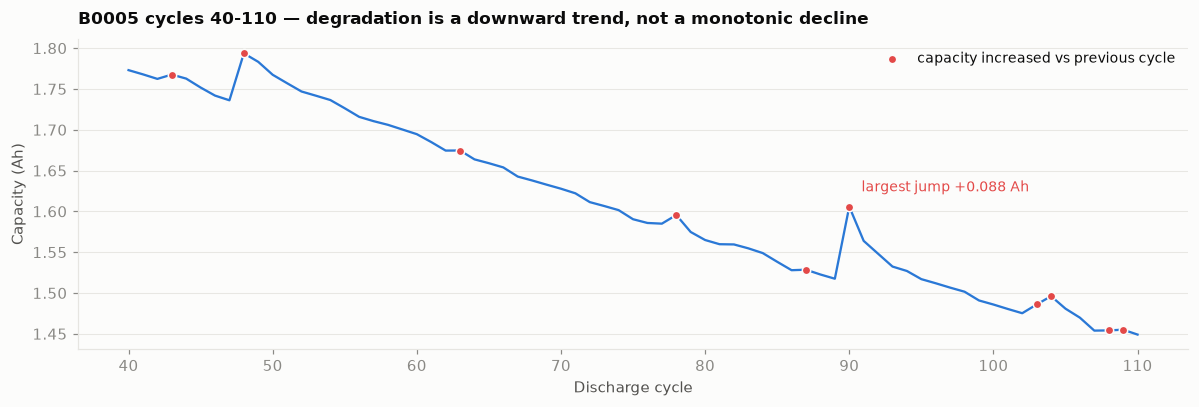

battery_id  n_steps  n_regen  regen_pct  regen_max_ah  regen_mean_ah  regen_max_pp_soh
     B0005      167       36       21.6        0.0883         0.0115              4.76
     B0006      167       27       16.2        0.1519         0.0287              7.46
     B0007      167       47       28.1        0.0982         0.0075              5.19
     B0018      131       21       16.0        0.1312         0.0319              7.08


In [13]:
g = cyc[cyc.battery_id == "B0005"].sort_values("cycle_id")
lo, hi = 40, 110
w = g[(g.cycle_id >= lo) & (g.cycle_id <= hi)]
dif = w.capacity_ah.diff()
up = w[dif > 0]

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(w.cycle_id, w.capacity_ah, color=SERIES["B0005"], lw=1.5)
ax.scatter(up.cycle_id, up.capacity_ah, s=30, color=ACCENT_BAD, zorder=5,
           edgecolor=SURFACE, linewidth=1.0, label="capacity increased vs previous cycle")
big = dif.idxmax()
ax.annotate(f"largest jump +{dif.max():.3f} Ah",
            (w.loc[big, "cycle_id"], w.loc[big, "capacity_ah"]),
            textcoords="offset points", xytext=(8, 10), fontsize=9, color=ACCENT_BAD)
style(ax, f"B0005 cycles {lo}-{hi} — degradation is a downward trend, not a monotonic decline",
      "Discharge cycle", "Capacity (Ah)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

print(regen.to_string(index=False))

Up to **28% of cycle-to-cycle steps go upward**, and the largest single jump is worth
7.5 percentage points of SOH — an order of magnitude above measurement noise.

This is the reason the EOL rule requires a *sustained* crossing: a cell can dip below the
threshold and climb back out. It is also why `rest_before_h` is computed as a feature —
the rest period preceding a cycle is what drives the recovery.

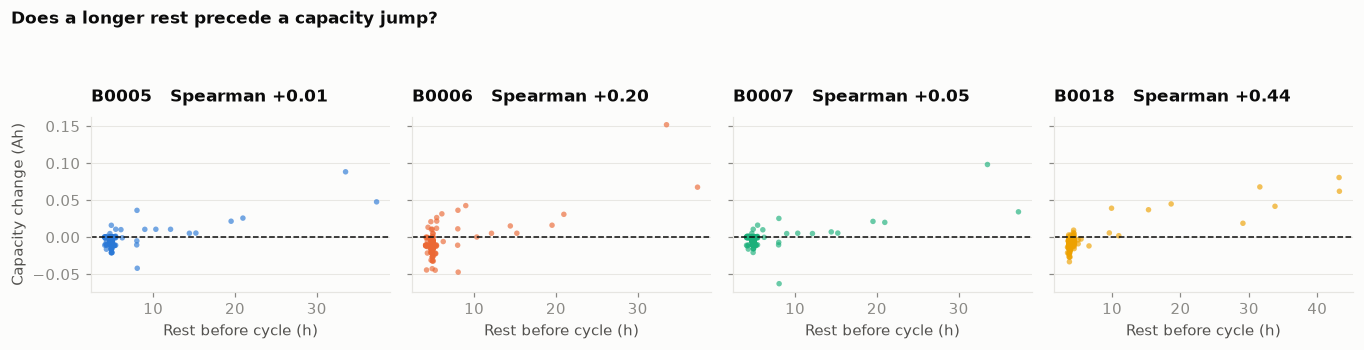

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2), sharey=True)
for ax, b in zip(axes, BATTERIES):
    g = cyc[cyc.battery_id == b].sort_values("cycle_id").copy()
    g["delta"] = g.capacity_ah.diff()
    s = g.dropna(subset=["delta", "rest_before_h"])
    s = s[s.rest_before_h < s.rest_before_h.quantile(0.99)]
    ax.scatter(s.rest_before_h, s.delta, s=13, color=SERIES[b], alpha=0.65,
               edgecolor="none")
    ax.axhline(0, color=INK, lw=1.0, ls="--")
    r = s.rest_before_h.corr(s.delta, method="spearman")
    style(ax, f"{b}   Spearman {r:+.2f}", "Rest before cycle (h)",
          "Capacity change (Ah)" if b == "B0005" else None)
fig.suptitle("Does a longer rest precede a capacity jump?",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

The relationship is positive but weak-to-moderate, and it varies by cell. That is worth
stating plainly: rest duration is a *contributing* factor, not a clean predictor of
regeneration. Phase 4 should look at rest duration jointly with cell age rather than
treating it as a standalone driver.

---

## Physical validation — does the parser recover known battery behaviour?

This is the strongest available correctness check. None of these relationships were fitted
or targeted; they either fall out of correctly parsed data or they don't.

Expected from the degradation physics:

- **CC-charge duration shortens** with age — an aged cell holds less charge, and a higher
  IR drop pushes terminal voltage to 4.2 V sooner.
- **CV duration lengthens** to compensate.
- **Charge-transfer resistance rises** as capacity falls.

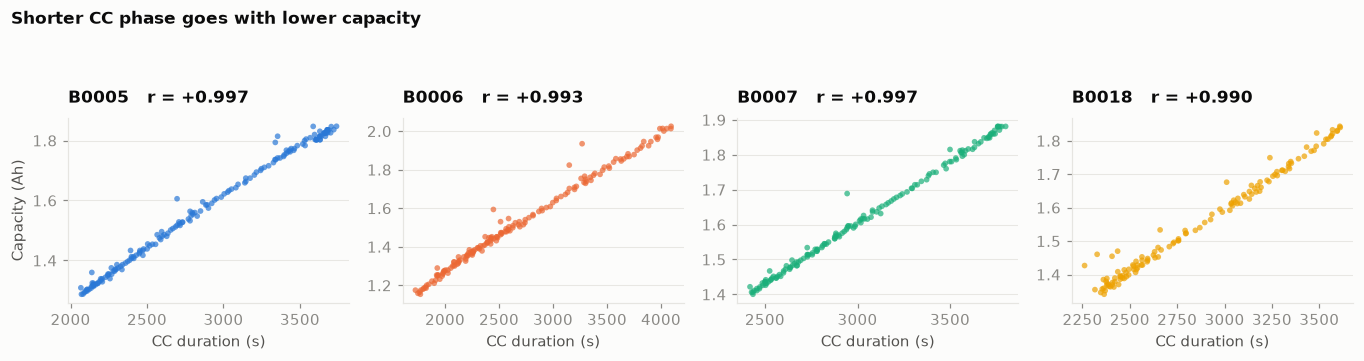

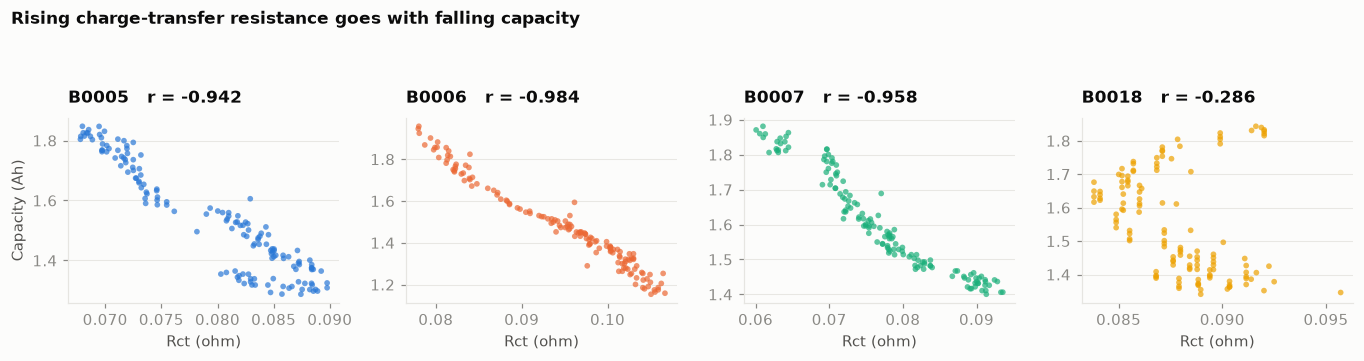

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3), sharey=False)
for ax, b in zip(axes, BATTERIES):
    g = cyc[(cyc.battery_id == b) & ~cyc.qc_any]
    ax.scatter(g.cc_duration_s, g.capacity_ah, s=14, color=SERIES[b], alpha=0.7,
               edgecolor="none")
    r = g.cc_duration_s.corr(g.capacity_ah)
    style(ax, f"{b}   r = {r:+.3f}", "CC duration (s)",
          "Capacity (Ah)" if b == "B0005" else None)
fig.suptitle("Shorter CC phase goes with lower capacity",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.3))
for ax, b in zip(axes, BATTERIES):
    g = cyc[(cyc.battery_id == b) & ~cyc.qc_any].dropna(subset=["rct_ohm"])
    ax.scatter(g.rct_ohm, g.capacity_ah, s=14, color=SERIES[b], alpha=0.7,
               edgecolor="none")
    r = g.rct_ohm.corr(g.capacity_ah)
    style(ax, f"{b}   r = {r:+.3f}", "Rct (ohm)",
          "Capacity (Ah)" if b == "B0005" else None)
fig.suptitle("Rising charge-transfer resistance goes with falling capacity",
             color=INK, x=0.012, ha="left", fontsize=11, fontweight="semibold")
plt.tight_layout(rect=[0, 0, 1, 0.9]); plt.show()

In [16]:
rows = []
for b in BATTERIES:
    g = cyc[cyc.battery_id == b]
    rows.append({
        "battery": b,
        "cycle~cc_dur": g.cycle_id.corr(g.cc_duration_s),
        "cycle~cv_dur": g.cycle_id.corr(g.cv_duration_s),
        "cc_dur~capacity": g.cc_duration_s.corr(g.capacity_ah),
        "rct~capacity": g.rct_ohm.corr(g.capacity_ah),
        "re~capacity": g.re_ohm.corr(g.capacity_ah),
        "v_recovery~capacity": g.v_recovery_v.corr(g.capacity_ah),
    })
val = pd.DataFrame(rows).set_index("battery").round(3)
print(val.to_string())
print()
print("Expected signs: cc_dur negative with cycle, cv_dur positive with cycle,")
print("cc_dur positive with capacity, resistance negative with capacity.")

         cycle~cc_dur  cycle~cv_dur  cc_dur~capacity  rct~capacity  re~capacity  v_recovery~capacity
battery                                                                                             
B0005          -0.821         0.836            0.822        -0.943       -0.885               -0.937
B0006          -0.863         0.809            0.862        -0.983       -0.971               -0.916
B0007          -0.748         0.829            0.747        -0.960       -0.952               -0.695
B0018          -0.619         0.540            0.586        -0.237       -0.784               -0.846

Expected signs: cc_dur negative with cycle, cv_dur positive with cycle,
cc_dur positive with capacity, resistance negative with capacity.


---

## B0018 diverges from the other three

Visible in the table above: every indicator is weaker for B0018, and `rct~capacity`
collapses from about -0.95 to -0.24. This matters because with only four cells, one
atypical cell is 25% of the dataset — and in leave-one-battery-out cross-validation it
becomes an entire fold.

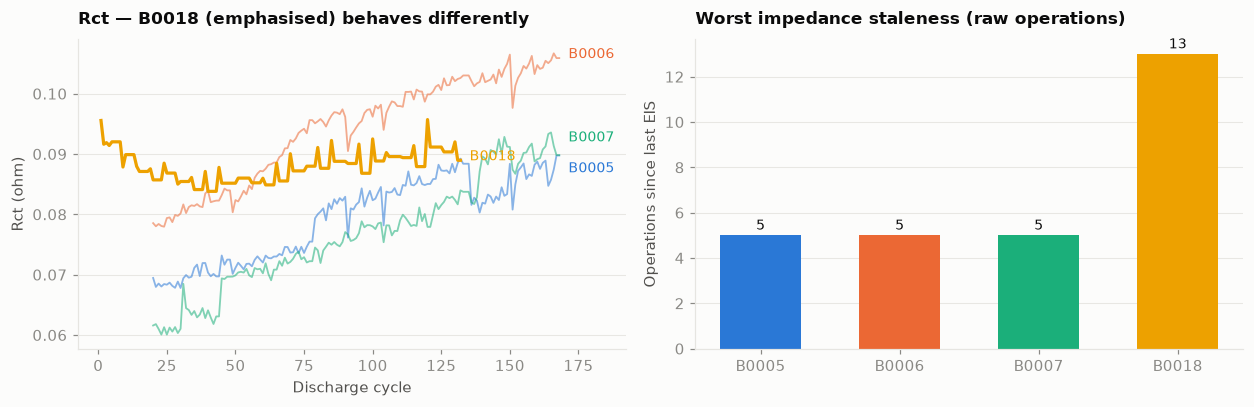

            cycles  imp_max_stale  n_impedance
battery_id                                    
B0005          168            5.0          149
B0006          168            5.0          149
B0007          168            5.0          149
B0018          132           13.0          132

B0018: fewer cycles, far sparser impedance, and the weakest indicator
correlations. Treat its LOBO fold as the hardest case - or investigate
whether its impedance record is partly defective.


In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.8))

# B0005 and B0007 finish at nearly the same Rct, so their end labels are
# pushed apart vertically rather than sharing one offset.
RCT_LABEL = {"B0005": (6, -11), "B0006": (6, 0), "B0007": (6, 9), "B0018": (6, 0)}
for b in BATTERIES:
    g = cyc[cyc.battery_id == b].sort_values("cycle_id").dropna(subset=["rct_ohm"])
    lw = 2.1 if b == "B0018" else 1.2
    al = 1.0 if b == "B0018" else 0.55
    a1.plot(g.cycle_id, g.rct_ohm, color=SERIES[b], lw=lw, alpha=al, label=b)
    a1.annotate(b, (g.cycle_id.iloc[-1], g.rct_ohm.iloc[-1]), textcoords="offset points",
                xytext=RCT_LABEL[b], fontsize=9, color=SERIES[b])
style(a1, "Rct — B0018 (emphasised) behaves differently", "Discharge cycle", "Rct (ohm)")
a1.set_xlim(right=a1.get_xlim()[1] * 1.09)

summary = cyc.groupby("battery_id").agg(
    cycles=("cycle_id", "size"),
    imp_max_stale=("impedance_age_ops", "max"),
    n_impedance=("re_ohm", "count"),
)
x = np.arange(len(summary))
a2.bar(x, summary.imp_max_stale, width=0.58,
       color=[SERIES[b] for b in summary.index])
for xi, v in zip(x, summary.imp_max_stale):
    a2.text(xi, v + 0.25, f"{v:.0f}", ha="center", fontsize=9, color=INK)
a2.set_xticks(x); a2.set_xticklabels(summary.index)
style(a2, "Worst impedance staleness (raw operations)", None, "Operations since last EIS")
plt.tight_layout(); plt.show()

print(summary.to_string())
print()
print("B0018: fewer cycles, far sparser impedance, and the weakest indicator")
print("correlations. Treat its LOBO fold as the hardest case - or investigate")
print("whether its impedance record is partly defective.")

---

## Summary

| # | Finding | Status | Handling |
|---|---|---|---|
| 1 | Discharge records include a relaxation tail (~9%) | resolved | active-segment masking; tail kept as `relax_duration_s`, `v_recovery_v` |
| 2 | Operation ordering differs between batteries | resolved | positional pairing via `merge_asof` on `op_index` |
| 3 | Cycle 1 is a partial charge on all four cells | resolved | `qc_charge_partial` |
| 4 | Five aborted charge operations | resolved | `qc_charge_aborted` |
| 5 | Early-life discharges overshoot the cut-off | **open** | flagged only — Phase 4 must assess capacity distortion |
| 6 | Identical telemetry volumes across three cells | not a bug | verified different values; synchronous testbed |

**Data state:** 636 discharge cycles, 606 clean. Three cells with an EOL label
(125 / 109 / 97), one right-censored.

**Carried into Phase 4:**

1. Finding 5 — is early capacity in B0006/B0007 distorted?
2. B0018's divergence — atypical cell, or defective impedance record?
3. 57 cycles with no impedance; decide drop / impute-with-indicator / restrict to cycle >= 20.
4. Rest duration and regeneration examined jointly with cell age.
5. Screen the health indicators already present here with Pearson **and** Spearman before
   adding curve-derivative features in Phase 6.